In [1]:
%matplotlib widget 
%load_ext autoreload
import os
import time
thisfiledir=os.path.abspath("")
deepracingrepodir=os.path.normpath(os.path.join(thisfiledir, "..", ".."))
import sys
sys.path = [os.path.join(deepracingrepodir, "deepracing_py"), os.path.join(deepracingrepodir, "DCNN-Pytorch"), thisfiledir] + sys.path
import matplotlib.transforms
import deepracing, deepracing_models.math_utils as mu, deepracing.path_utils
from deepracing_models.math_utils.bayesian_filtering import BayesianFilter
from deepracing_models.math_utils.bounds_checking import BoundsChecker
from deepracing_models.math_utils.statistics import CollisionProbabilityEstimator
from deepracing_models.math_utils.dynamics import ExceedLimitsProbabilityEstimator
import torch, numpy as np
from scipy.spatial.transform import Rotation
import matplotlib.figure, matplotlib.axes, matplotlib.collections, matplotlib.patches
from matplotlib import pyplot as plt
import torch.distributions
import scipy.interpolate, scipy.spatial
from tqdm import tqdm
import PIL, PIL.Image, PIL.ImageOps
import utils
searchdirs = []
try:
    searchdirs.extend(os.environ["F1_MAP_DIRS"].split(os.pathsep))
except ImportError as e:
    pass
try:
    import ament_index_python # type: ignore
    searchdirs.append(os.path.join(ament_index_python.get_package_share_directory("deepracing_launch"), "maps"))
except ImportError as e:
    pass
except ament_index_python.packages.PackageNotFoundError as e:
    pass
transform_to_map=True
trackmap = deepracing.searchForTrackmap("Britain", searchdirs, align=True, transform_to_map=transform_to_map)

searching LOR in /home/trent/deepracingws/src/deepracing_ros/deepracing_launch/maps
searching LVMS in /home/trent/deepracingws/src/deepracing_ros/deepracing_launch/maps
searching Britain in /home/trent/deepracingws/src/deepracing_ros/deepracing_launch/maps
Yay!


In [2]:
ego_scaledown = 0.875
skip=2
clip = -1 
raceline_structured : np.ndarray = trackmap.raceline
line_all_points = torch.as_tensor(np.concatenate([raceline_structured["x"], raceline_structured["y"]], axis=1), dtype=torch.float32, device=torch.device("cuda:0"))
times_in = raceline_structured["time"][:,0].astype(np.float64)
arclength_in = raceline_structured["arclength"][:,0].astype(np.float64)
interp_spline : scipy.interpolate.BSpline = \
    scipy.interpolate.make_interp_spline(times_in, arclength_in, k=3)#, bc_type="periodic")
interp_spline_speeds = interp_spline(times_in, nu=1)
line_all_times = torch.as_tensor(times_in).type_as(line_all_points)
line_all_speeds = ego_scaledown*torch.as_tensor(interp_spline_speeds).type_as(line_all_points).squeeze(-1)

line_subsamp = (line_all_points[::skip])[:clip]
speeds_subsamp = (line_all_speeds[::skip])[:clip]

print("Building raceline helper")
raceline_helper : mu.RacelineHelper = mu.RacelineHelper.from_closed_path(
    torch.concatenate([line_subsamp, line_subsamp[[0,]]], dim=0),
    torch.concatenate([speeds_subsamp, speeds_subsamp[[0,]]], dim=0)
    )#.to(device=line_all_points.device, dtype=line_all_points.dtype)
print("Built raceline helper")


car_width = 2.0
car_length = 5.5
print("Building centerline helper")
centerline_structured : np.ndarray = trackmap.centerline
position_keys =["x", "y", "z"]
quaternion_keys = ["i", "j", "k", "w"]
width_map = trackmap.width_map

shrink_factor = 2.5
left_widths = shrink_factor*torch.as_tensor(width_map["ob_distance"], dtype=line_all_times.dtype).squeeze(-1) + 0.25*car_width
right_widths = shrink_factor*torch.as_tensor(width_map["ib_distance"], dtype=line_all_times.dtype).squeeze(-1) - 0.25*car_width

centerline_dense_full = torch.as_tensor(np.concatenate([width_map[k] for k in position_keys], axis=1)).type_as(left_widths)
centerline_dense = centerline_dense_full[...,[0,1]]
centerline_quats = np.concatenate([width_map[k] for k in quaternion_keys], axis=1)
centerline_rots : Rotation = Rotation.from_quat(centerline_quats/np.linalg.norm(centerline_quats, ord=2.0, axis=-1, keepdims=True))
centerline_rotmats : torch.Tensor = torch.as_tensor(centerline_rots.as_matrix(), device=centerline_dense.device, dtype=centerline_dense.dtype)
ib_dense_full = (centerline_dense_full + centerline_rotmats[...,1]*right_widths[:,None]).cpu()
ib_dense = ib_dense_full[...,[0,1]]
ob_dense_full = (centerline_dense_full + centerline_rotmats[...,1]*left_widths[:,None]).cpu()
ob_dense = ob_dense_full[...,[0,1]]

left_widths = torch.norm(ob_dense - centerline_dense, p=2.0, dim=-1)
right_widths = -torch.norm(ib_dense - centerline_dense, p=2.0, dim=-1)
print("Built centerline helper")

print("Building boundary helpers")

innerbound_helper = mu.SimplePathHelper.from_closed_path(ib_dense, 0.5).to(dtype=line_all_points.dtype, device=line_all_points.device)
outerbound_helper = mu.SimplePathHelper.from_closed_path(ob_dense, 0.5).to(dtype=line_all_points.dtype, device=line_all_points.device)

print("Built boundary helpers")


Building raceline helper
Built raceline helper
Building centerline helper
Built centerline helper
Building boundary helpers
Built boundary helpers


In [57]:

Nparticles = int(round(1.25*(2**9)))
dT_desired = 5.0
# idx0 = int(np.random.randint(0, high=int(round(0.9*line_all_times.shape[0]))))
# t0 = float(line_all_times[idx0].item())
# t0 = 25.330
# t0 = 55.591
# t0 = 8.25
# t0 = 75.16829681396484
# t0 = 46.25149917602539
# t0 = 46.551
t0 = 52.30149841308594 + 3.0
print("t0:", t0)
bounds_checker : BoundsChecker = (
    BoundsChecker(gauss_order=20, dT=dT_desired, stdev=0.875,
        refline_points=centerline_dense, dr_samp=0.1, left_widths=left_widths, right_widths=right_widths).eval()
).to(dtype=line_all_points.dtype, device=line_all_points.device)
bounds_checker.rebuild_kdtree()

tfit = torch.linspace(0.0, dT_desired, steps=120).type_as(line_all_times)
tglobal_ego = tfit + t0
tfit = tfit[None]#.expand(Nparticles, -1)
rfit_, Pfit_, Vfit_, _ = raceline_helper(t=tglobal_ego, deriv=True)

# print(rfit_)
# exit(0)
rfinal : torch.Tensor = rfit_[[-1,]].expand(Nparticles).clone()

Pfit : torch.Tensor = Pfit_[None]
Vfit : torch.Tensor = Vfit_[None]
Taufit = Vfit/torch.norm(Vfit, p=2.0, dim=-1, keepdim=True)
Nufit = Taufit[...,[1,0]].clone()
Nufit[...,0]*=-1.0


initial_time_ahead = 0.1
tglobal_target = torch.linspace(tglobal_ego[0].item() + initial_time_ahead, tglobal_ego[0].item() + initial_time_ahead + dT_desired*.9, steps=tglobal_ego.shape[0]).type_as(tglobal_ego)
_, Pfit_target, Vfit_target, _ = raceline_helper(t=tglobal_target, deriv=True)

Taufit_target = Vfit_target/torch.norm(Vfit_target, p=2.0, dim=-1, keepdim=True)
Nufit_target = Taufit_target[:,[1,0]].clone()
Nufit_target[:,0]*=-1.0

Pfit_target += 3.0*car_width



Targetvehicle_curve, _ = mu.compositeBezierFit(tfit[[0,]], Pfit_target[None], 4, 
                                                            #   dYdT_0=V0[None],
                                                              Y_0=Pfit_target[[0,]],
                                                              Y_f=Pfit_target[[-1,]],
                                                              kbezier=3,
                                                              constraint_level=2)
Targetvehicle_curve = Targetvehicle_curve[0]


Curveparticles_mean, Curvefit_tswitch = mu.compositeBezierFit(tfit, Pfit, Targetvehicle_curve.shape[-3], 
                                                              Y_0=Pfit[0,[0,]],#.expand(Nparticles, 2),
                                                              dYdT_0=Vfit[0,[0,]],#.expand(Nparticles, 2),
                                                              Y_f=Pfit[0,[-1,]],#.expand(Nparticles, 2),
                                                              dYdT_f=Vfit[0,[-1,]],#.expand(Nparticles, 2),
                                                              kbezier=Targetvehicle_curve.shape[-2]-1,
                                                              constraint_level=2)
Curveparticle_tstart = Curvefit_tswitch[:,:-1].expand(Nparticles, Curvefit_tswitch.shape[-1]-1).clone()
Curveparticle_dT = torch.diff(Curvefit_tswitch, dim=1).expand(Nparticles, Curvefit_tswitch.shape[-1]-1).clone()
Curveparticles = Curveparticles_mean.expand([Nparticles,] + list(Curveparticles_mean.shape[1:])).clone()
Curveparticles_mean_deriv = (Curveparticles_mean.shape[-2]-1)*torch.diff(Curveparticles_mean, dim=-2)/Curveparticle_dT[[0,],...,None,None]
image_scale = 1.5*shrink_factor
lat_buffer = 0.5*image_scale*car_width
long_buffer = 0.5*image_scale*car_length
collision_probability_estimator : CollisionProbabilityEstimator = CollisionProbabilityEstimator(
    12, dT_desired, 16, lat_buffer, long_buffer
    ).to(dtype=Pfit.dtype, device=Pfit.device)
gauss2d_integrator = collision_probability_estimator.gaussian_pdf_integrator


t0: 55.30149841308594


In [58]:
Targetvehicle_curve_deriv = (Targetvehicle_curve.shape[-2]-1)*torch.diff(Targetvehicle_curve,n=1,dim=-2)/Curveparticle_dT[0,:,None,None]
print("Targetvehicle_curve.shape:", Targetvehicle_curve.shape)
print("Targetvehicle_curve_deriv.shape:", Targetvehicle_curve_deriv.shape)
TV_positions, idxbuckets = mu.compositeBezierEval(Curveparticle_tstart[[0,]], Curveparticle_dT[[0,]], Targetvehicle_curve[None], collision_probability_estimator.gl1d.eta[None])
TV_positions = TV_positions[0]
TV_velocities, _ = mu.compositeBezierEval(Curveparticle_tstart[[0,]], Curveparticle_dT[[0,]], Targetvehicle_curve_deriv[None], collision_probability_estimator.gl1d.eta[None], idxbuckets=idxbuckets)
TV_velocities = TV_velocities[0]
TV_speeds = torch.norm(TV_velocities, p=2.0, dim=-1)
TV_tangents = TV_velocities/TV_speeds[...,None]
TV_normals = TV_tangents[...,[1,0]].clone()
TV_normals[...,0]*=-1.0
TV_rotmats = torch.stack([TV_tangents, TV_normals], dim=-1)


lateralvals_01 = 0.5*torch.linspace(-car_width, car_width, steps=3).type_as(Targetvehicle_curve)
longvals_01 = 0.5*torch.linspace(-car_length, car_length, steps=4).type_as(Targetvehicle_curve)
boxpoints_target_01 = torch.stack(torch.meshgrid(longvals_01, lateralvals_01, indexing='ij'), dim=0).reshape(2,-1).T
print(boxpoints_target_01)
# exit(0)
TV_box_positions = (TV_rotmats@boxpoints_target_01[None].transpose(-2,-1)).transpose(-2,-1) + TV_positions[:,None]


Targetvehicle_curve.shape: torch.Size([4, 4, 2])
Targetvehicle_curve_deriv.shape: torch.Size([4, 3, 2])
tensor([[-2.7500, -1.0000],
        [-2.7500,  0.0000],
        [-2.7500,  1.0000],
        [-0.9167, -1.0000],
        [-0.9167,  0.0000],
        [-0.9167,  1.0000],
        [ 0.9167, -1.0000],
        [ 0.9167,  0.0000],
        [ 0.9167,  1.0000],
        [ 2.7500, -1.0000],
        [ 2.7500,  0.0000],
        [ 2.7500,  1.0000]], device='cuda:0')


In [59]:

p0 : torch.Tensor = Curveparticles_mean[0,0,0].clone()
pf : torch.Tensor = Curveparticles_mean[0,-1,-1].clone() 
((cl_r0, cl_rf), (cl_p0, cl_pf), (cl_tau_0, cl_tau_f), (cl_nu_0, cl_nu_f), _) = bounds_checker.refline_helper.closest_point_approximate(torch.stack([p0, pf]), newton_iterations=5)

cl_R0 = torch.stack([cl_tau_0, cl_nu_0], dim=1)
cl_Rf = torch.stack([cl_tau_f, cl_nu_f], dim=1)

ib_r0, ib_rf = innerbound_helper.y_axis_intersection(torch.stack([cl_p0, cl_pf]), torch.stack([cl_R0, cl_Rf], dim=0))
ob_r0, ob_rf = outerbound_helper.y_axis_intersection(torch.stack([cl_p0, cl_pf]), torch.stack([cl_R0, cl_Rf], dim=0))

asdf = innerbound_helper(torch.linspace(ib_r0, ib_rf, steps=300).type_as(ib_r0))
ib_plot : torch.Tensor = asdf[0].clone()
asdf = outerbound_helper(torch.linspace(ob_r0, ob_rf, steps=ib_plot.shape[0]).type_as(ob_r0))
ob_plot : torch.Tensor = asdf[0].clone()




(-66.4865951538086, 242.9046173095703)

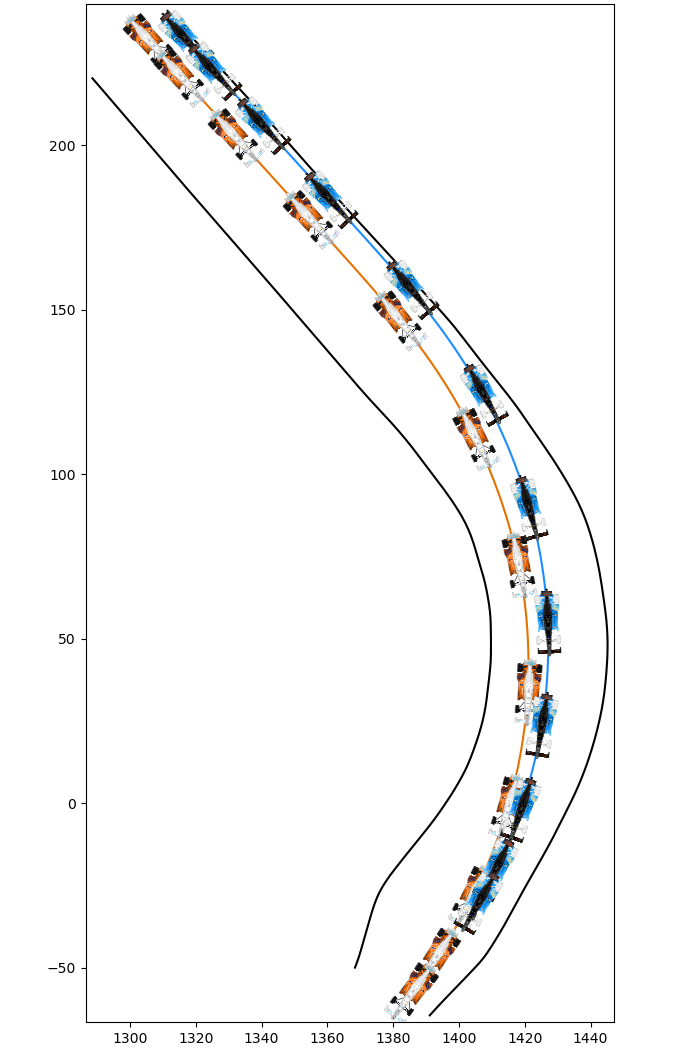

In [60]:
import matplotlib.colors
figname="Overtake Slice"
plt.close(fig=figname)
columnwidth=3.5
figsize=2.0*np.asarray([columnwidth, 1.5*columnwidth])
fig, ax = plt.subplots(label=figname, figsize=figsize, layout="constrained", frameon=False)

egoplotline, = ax.plot(*(Pfit[0].cpu().T), label="Ego Trajectory", color=utils.COLORS.UVA_ORANGE)
egoplotline.set_zorder(egoplotline.get_zorder()-1)
targetplotline, = ax.plot(*(Pfit_target.cpu().T), label="Target Trajectory", linestyle=egoplotline.get_linestyle(), color=1.0-utils.COLORS.UVA_ORANGE)
targetplotline.set_zorder(egoplotline.get_zorder())

ibplotline, = ax.plot(*(ib_plot.cpu().T), color="black", label="Track Boundaries")
ibplotline.set_zorder(egoplotline.get_zorder())
obplotline, = ax.plot(*(ob_plot.cpu().T), color=ibplotline.get_color(), linestyle=ibplotline.get_linestyle())
obplotline.set_zorder(egoplotline.get_zorder())

allpoints = torch.cat([Pfit[0], Pfit_target, ob_plot, ib_plot], dim=0)

carimage : PIL.Image.Image = PIL.Image.open(os.path.join(thisfiledir, "assets", "cavalier_transparent.png"))
invertedcarimage : PIL.Image.Image = PIL.Image.open(os.path.join(thisfiledir, "assets", "cavalier_transparent_inverted.png"))
# invertedcarimage : PIL.Image.Image = PIL.ImageOps.invert(carimage.convert('RGB')).convert('RGBA')
# invertedcarimage.putalpha(carimage.getchannel("A"))
# gauss2d_integrator collision_probability_estimator.gl1d.eta
flip = torch.as_tensor([-1.0, 1.0]).type_as(Pfit)
timage = collision_probability_estimator.gl1d.eta#torch.linspace(tfit[0,0], tfit[0,-1], steps=30).type_as(tfit)
ego_pimage, idxbuckets = mu.compositeBezierEval(Curveparticle_tstart[[0,]], Curveparticle_dT[[0,]], Curveparticles_mean, timage[None])
ego_pimage = ego_pimage[0]
ego_vimage, _ = mu.compositeBezierEval(Curveparticle_tstart[[0,]], Curveparticle_dT[[0,]], Curveparticles_mean_deriv, timage[None], idxbuckets=idxbuckets)
ego_vimage = ego_vimage[0]
ego_tauimage = ego_vimage/torch.norm(ego_vimage, dim=-1, p=2.0, keepdim=True)
ego_rotmatimage = torch.stack([ego_tauimage, ego_tauimage[:,[1,0]]*flip[None]], dim=-1)
target_pimage, idxbuckets = mu.compositeBezierEval(Curveparticle_tstart[[0,]], Curveparticle_dT[[0,]], Targetvehicle_curve[None], timage[None])
target_pimage = target_pimage[0]
target_vimage, _ = mu.compositeBezierEval(Curveparticle_tstart[[0,]], Curveparticle_dT[[0,]], Targetvehicle_curve_deriv[None], timage[None], idxbuckets=idxbuckets)
target_vimage = target_vimage[0]
target_tauimage = target_vimage/torch.norm(target_vimage, dim=-1, p=2.0, keepdim=True)
target_rotmatimage = torch.stack([target_tauimage, target_tauimage[...,[1,0]]*flip[None]], dim=-1)
for idx_image in range(timage.shape[0]):
    _,_,mplimage1=utils.plot_image(ax, carimage, ego_pimage[idx_image], ego_tauimage[idx_image], car_width, car_length, image_scale=image_scale)
    mplimage1.set_zorder(mplimage1.get_zorder()+1)
    _,_,mplimage2=utils.plot_image(ax, invertedcarimage, target_pimage[idx_image], target_tauimage[idx_image], car_width, car_length, image_scale=image_scale)
    mplimage2.set_zorder(mplimage1.get_zorder())
gaussianmeans_01 = (image_scale*torch.stack(torch.meshgrid([
    0.5*torch.linspace(-car_length, car_length, steps=4),
    0.5*torch.linspace(-car_width, car_width, steps=3)
], indexing="ij"), dim=0)).reshape(2,-1).T.type_as(target_rotmatimage)
gaussianmeans_target = (target_rotmatimage[:,None] @ gaussianmeans_01[None,...,None]).squeeze(-1) + target_pimage[:,None]
#, collision_probs, overall_lambdas, overall_collision_free_probs
logtwopi = float(np.log(2.0*np.pi))
target_stdevs = (0.9*image_scale*torch.as_tensor([1.0, 0.75]).type_as(target_rotmatimage))[None].expand(target_rotmatimage.shape[:-1])
target_logstdevs = (logtwopi + torch.log(target_stdevs).sum(dim=-1))
target_stdev_inv_matrix = (torch.diag_embed(1.0/target_stdevs)@target_rotmatimage.transpose(-2,-1))
gauss_pts, gaussian_pdf_vals, dense_collision_probs = \
    gauss2d_integrator(gaussianmeans_target, target_stdev_inv_matrix, target_logstdevs,
                                    ego_rotmatimage[None], ego_pimage[None])
gauss_pts = gauss_pts[0]
dense_collision_probs = dense_collision_probs[0].clip(0.0, 1.0)
gaussian_pdf_vals=gaussian_pdf_vals[0]


minx, maxx = allpoints[:,0].min().item() - 0.1*image_scale*car_length, allpoints[:,0].max().item() + 0.1*image_scale*car_length,
miny, maxy = allpoints[:,1].min().item() - 0.1*image_scale*car_length, allpoints[:,1].max().item() + 0.1*image_scale*car_length,
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)


# ax.set_aspect(aspect="equal", adjustable="datalim")

(133.5375213623047, 169.8283233642578)

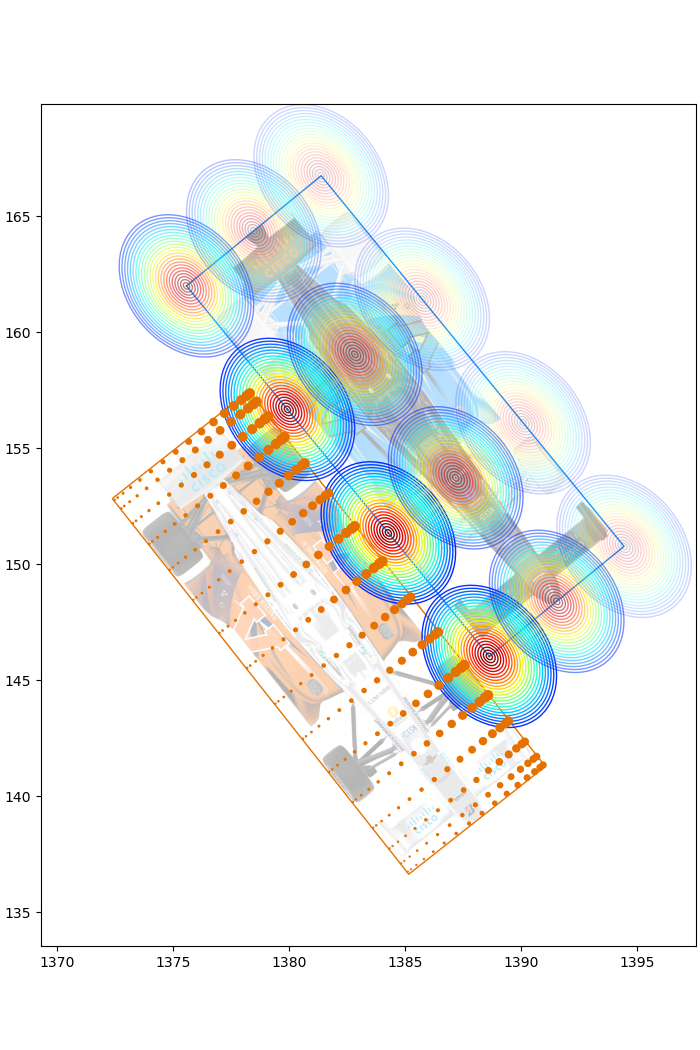

In [ ]:
# %autoreload 2
# import utils
import matplotlib.patches
import torch.distributions
figname="Overtake Inset"
plt.close(fig=figname)
fig_inset, ax_inset = plt.subplots(label=figname, figsize=figsize, layout="constrained", frameon=False)
visible_index = torch.argmin(torch.abs(timage-dT_desired*0.375))
#torch.argmax(((ego_pimage[:,0]>=xlim_inset[0])*(ego_pimage[:,0]<=xlim_inset[1])*(ego_pimage[:,1]>=ylim_inset[0])*(ego_pimage[:,1]<=ylim_inset[1])).float())
alpha=0.3
Tmat_ego, _, egoim_inset = utils.plot_image(ax_inset, carimage, ego_pimage[visible_index], ego_tauimage[visible_index], car_width, car_length, 
                                  image_scale=image_scale, alpha=alpha)
egoim_inset.set_zorder(1)
Tmat_target, _, targetim_inset = utils.plot_image(ax_inset, invertedcarimage, target_pimage[visible_index], target_tauimage[visible_index], car_width, car_length, 
                                     image_scale=image_scale, alpha=alpha)
targetim_inset.set_zorder(egoim_inset.get_zorder())
bbox_ego = ((Tmat_ego[0:2,0:2] @ (image_scale*torch.stack(torch.meshgrid([
    0.5*torch.as_tensor([-car_length, car_length]),
    0.5*torch.as_tensor([-car_width, car_width])
], indexing="ij"), dim=0).reshape(2,-1).type_as(Tmat_ego))).T + Tmat_ego[0:2,2])[[0,1,3,2]]
bbox_target = ((Tmat_target[0:2,0:2] @ (image_scale*torch.stack(torch.meshgrid([
    0.5*torch.as_tensor([-car_length, car_length]),
    0.5*torch.as_tensor([-car_width, car_width])
], indexing="ij"), dim=0).reshape(2,-1).type_as(Tmat_target))).T + Tmat_target[0:2,2])[[0,1,3,2]]
integration_vals = dense_collision_probs[visible_index]
ellipse_alphas = ((integration_vals/torch.max(integration_vals))**0.25).clip(0.2, 1.0)
angle = torch.atan2(Tmat_target[1,0], Tmat_target[0,0]).item()
num_ellipses=25
ellipse_patches = utils.plot_gaussian(ax_inset, gaussianmeans_target[visible_index,0], target_stdevs[visible_index], angle, num_ellipses=num_ellipses, alpha=ellipse_alphas[0].item())
for i in range(1, gaussianmeans_target.shape[1]):
    ellipse_patches.extend(utils.plot_gaussian(ax_inset, gaussianmeans_target[visible_index,i], target_stdevs[visible_index], angle, num_ellipses=num_ellipses, alpha=ellipse_alphas[i].item()))

bbox_ego_patch : matplotlib.patches.Polygon = ax_inset.add_patch(matplotlib.patches.Polygon(bbox_ego.cpu().numpy().tolist(), fill=None, edgecolor=egoplotline.get_color()))
bbox_target_patch : matplotlib.patches.Polygon = ax_inset.add_patch(matplotlib.patches.Polygon(bbox_target.cpu().numpy().tolist(), fill=None, edgecolor=targetplotline.get_color()))

gaussian_pdf_vals_visible = gaussian_pdf_vals[:,visible_index]
glpoints_pdfratios = torch.max(gaussian_pdf_vals_visible, dim=1)[0]/torch.max(gaussian_pdf_vals_visible)
glpoints_sizes = (2**5.5)*(glpoints_pdfratios**0.75)
glpoints_scatter = ax_inset.scatter(*(gauss_pts[:,visible_index].T.cpu()), color=egoplotline.get_color(), s=glpoints_sizes.cpu(), zorder=3)
# ax_inset.scatter(*(gaussianmeans_target[visible_index].T.cpu()), color=targetplotline.get_color(), s=(2**4.5), zorder=3)
all_points = torch.cat([gauss_pts[:,visible_index], gaussianmeans_target[visible_index], bbox_ego, bbox_target], dim=0)


ax_inset.set_xlim(all_points[:,0].min().item() - .15*image_scale*car_length, all_points[:,0].max().item() + .15*image_scale*car_length)
ax_inset.set_ylim(all_points[:,1].min().item() - .15*image_scale*car_length, all_points[:,1].max().item() + .15*image_scale*car_length)





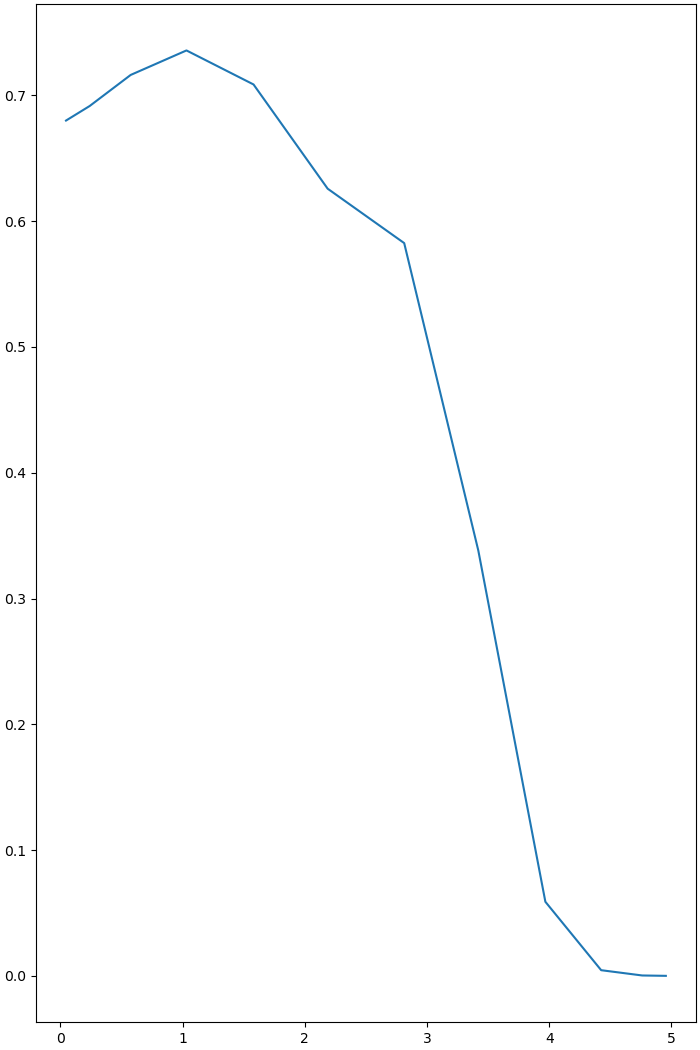

In [62]:
figname="Collision Prob Vs Time"
plt.close(fig=figname)
fig_time, ax_time = plt.subplots(label=figname, figsize=figsize, layout="constrained")
no_collision_probs = torch.prod(1.0 - dense_collision_probs, dim=-1)
overall_collision_probs = 1.0 - no_collision_probs
ax_time.plot(timage.cpu(), overall_collision_probs.cpu())